In [2]:
import glob
import random
import numpy as np
import cv2
from tensorflow.lite.python.interpreter import Interpreter
import matplotlib.pyplot as plt
import os

def detection_test_tflite(model_path, images_directory, labels_file, 
                            min_confidence=0.5, num_images=10, results_path='/content/results', text_output_only=False):
    # Get image file paths
    image_extensions = ['jpg', 'JPG', 'png', 'bmp']
    image_files = [file for ext in image_extensions for file in glob.glob(f'{images_directory}/*.{ext}')]

    # Load labels
    with open(labels_file, 'r') as file:
        labels = [line.strip() for line in file.readlines()]

    # Set up the model
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Get input and output tensor
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Determine input shape and data type
    input_shape = input_details[0]['shape']
    is_float_model = (input_details[0]['dtype'] == np.float32)

    # Select a random subset of images to test
    selected_images = random.sample(image_files, num_images)

    # Process each image
    for image_path in selected_images:
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        resized_image = cv2.resize(image_rgb, (input_shape[2], input_shape[1]))
        input_data = np.expand_dims(resized_image, axis=0)

        # Normalize data 
        if is_float_model:
            input_data = (input_data - 127.5) / 127.5
            input_data = input_data.astype(np.float32)  

        # Run detection
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
  
        # Retrieve output
        boxes = interpreter.get_tensor(output_details[1]['index'])[0]
        classes = interpreter.get_tensor(output_details[3]['index'])[0]
        scores = interpreter.get_tensor(output_details[0]['index'])[0]

        detections = []

        # Handle detected objects
        for i, score in enumerate(scores):
            if min_confidence < score <= 1.0:
                ymin, xmin, ymax, xmax = boxes[i]
                (left, right, top, bottom) = (xmin * image.shape[1], xmax * image.shape[1],
                                              ymin * image.shape[0], ymax * image.shape[0])

                # Draw detections
                cv2.rectangle(image, (int(left), int(top)), (int(right), int(bottom)), (10, 255, 0), 2)
                label = f'{labels[int(classes[i])]}: {int(score * 100)}%'
                cv2.putText(image, label, (int(left), int(top) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                detections.append([labels[int(classes[i])], score, left, top, right, bottom])

        # Display or save output
        if not text_output_only:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.show()
        else:
            image_fn = os.path.basename(image_path)
            base_fn, _ = os.path.splitext(image_fn)
            result_txt_path = os.path.join(results_path, f'{base_fn}.txt')

            with open(result_txt_path, 'w') as f:
                for det in detections:
                    f.write(f'{det[0]} {det[1]:.4f} {int(det[2])} {int(det[3])} {int(det[4])} {int(det[5])}\n')



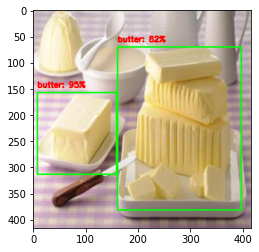

In [5]:

# This is an example of testing, the testing was done in Google Colab due to the large size of the image folder. 
detection_test_tflite("../model/ssd_model_v2/detect.tflite", "../img", "../model/ssd_model_v2/labelmap.txt", 0.5, 1)